In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [17]:
DATA_DIR = r"C:\Users\Mathumitha\Desktop\Mathu\veg"  
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "validation")
TEST_DIR  = os.path.join(DATA_DIR, "test")


In [18]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)


Found 858 files belonging to 10 classes.


In [20]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 98 files belonging to 10 classes.


In [21]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,     
    label_mode="int"
)

Found 100 files belonging to 10 classes.


In [22]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("\nClasses:", class_names)
print("Number of classes:", num_classes)



Classes: ['beetroot', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'cucumber', 'eggplant', 'potato', 'raddish', 'tomato']
Number of classes: 10


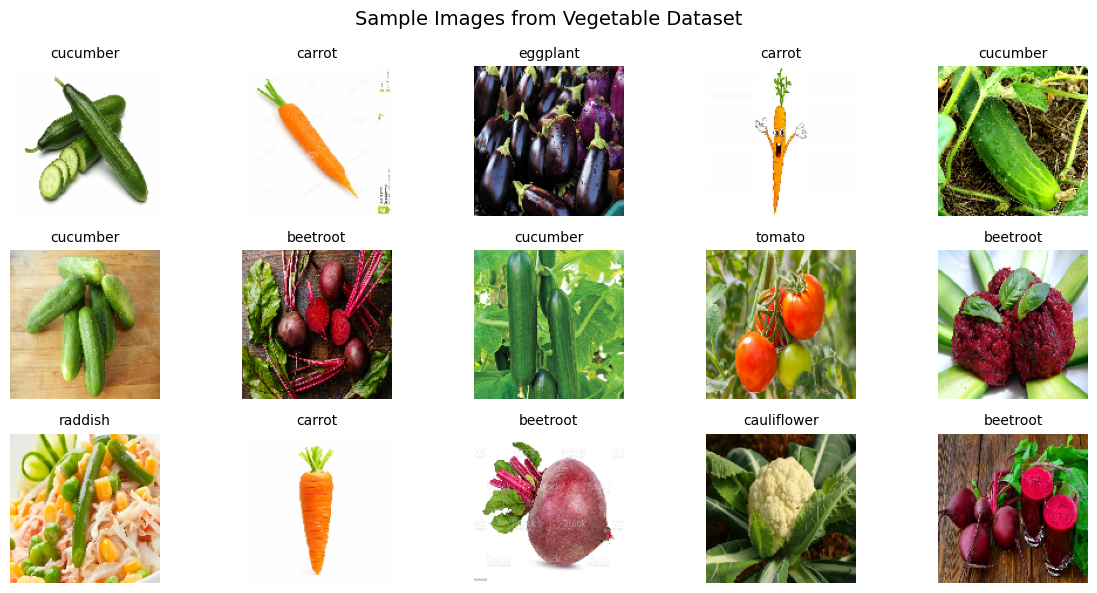

In [23]:
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(15):
        plt.subplot(3, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])], fontsize=10)
        plt.axis("off")

plt.suptitle("Sample Images from Vegetable Dataset", fontsize=14)
plt.tight_layout()
plt.show()


In [24]:
for images, labels in train_ds.take(1):
    print("\nPixel value range (before model rescaling):")
    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())



Pixel value range (before model rescaling):
Min: 0.0
Max: 255.0


In [25]:

for images, labels in train_ds.take(1):
    print("\nBefore normalization:")
    print("Min:", tf.reduce_min(images).numpy(), "Max:", tf.reduce_max(images).numpy())

for images, labels in train_ds.take(1):
    print("\nPixel value range:")
    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())



Before normalization:
Min: 0.0 Max: 255.0

Pixel value range:
Min: 0.0
Max: 255.0


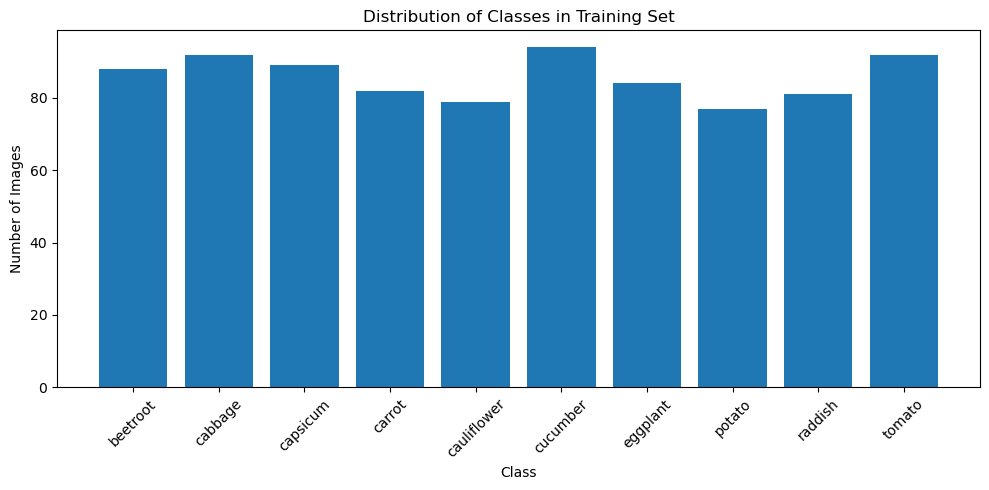


Images per class:
beetroot: 88
cabbage: 92
capsicum: 89
carrot: 82
cauliflower: 79
cucumber: 94
eggplant: 84
potato: 77
raddish: 81
tomato: 92


In [26]:
label_counts = np.zeros(num_classes, dtype=int)

for _, labels in train_ds:
    labels_np = labels.numpy()
    for v in labels_np:
        label_counts[int(v)] += 1

plt.figure(figsize=(10, 5))
plt.bar(class_names, label_counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Classes in Training Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nImages per class:")
for name, count in zip(class_names, label_counts):
    print(f"{name}: {count}")


In [27]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

model = keras.Sequential([
    layers.Input(shape=(128,128,3)),

    data_augmentation, 
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

In [28]:
model.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.002),
    loss="sparse_categorical_crossentropy",   
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]
print("\nModel compiled and ready to train!")


Model compiled and ready to train!


In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 503ms/step - accuracy: 0.1876 - loss: 2.2418 - val_accuracy: 0.3367 - val_loss: 1.9122 - learning_rate: 0.0020
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 445ms/step - accuracy: 0.3042 - loss: 1.8946 - val_accuracy: 0.4286 - val_loss: 1.4932 - learning_rate: 0.0020
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 483ms/step - accuracy: 0.3636 - loss: 1.7277 - val_accuracy: 0.5714 - val_loss: 1.4303 - learning_rate: 0.0020
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 455ms/step - accuracy: 0.4429 - loss: 1.5255 - val_accuracy: 0.4796 - val_loss: 1.2444 - learning_rate: 0.0020
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 484ms/step - accuracy: 0.4476 - loss: 1.4854 - val_accuracy: 0.7449 - val_loss: 0.9618 - learning_rate: 0.0020
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 437ms/step - accuracy: 0.4755 - loss: 1.3847 - val_accuracy: 0.6429 - val_loss: 1.0368 - learning_rate: 0.0020
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 476ms/step - accuracy: 0.5082 - loss: 1.

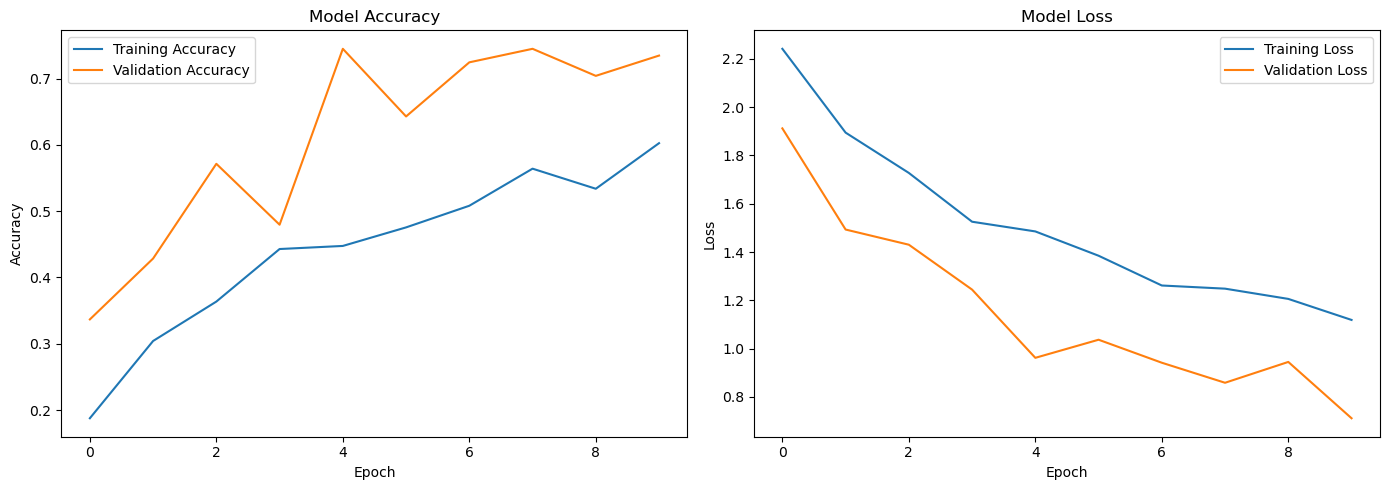

In [38]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 74.00%
Test Loss: 0.7071


In [40]:
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

y_pred_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))


Classification Report:
              precision    recall  f1-score   support

    beetroot      0.750     0.900     0.818        10
     cabbage      0.714     1.000     0.833        10
    capsicum      0.438     0.700     0.538        10
      carrot      1.000     0.600     0.750        10
 cauliflower      0.833     1.000     0.909        10
    cucumber      0.714     0.500     0.588        10
    eggplant      0.909     1.000     0.952        10
      potato      1.000     0.600     0.750        10
     raddish      0.800     0.800     0.800        10
      tomato      0.500     0.300     0.375        10

    accuracy                          0.740       100
   macro avg      0.766     0.740     0.731       100
weighted avg      0.766     0.740     0.731       100



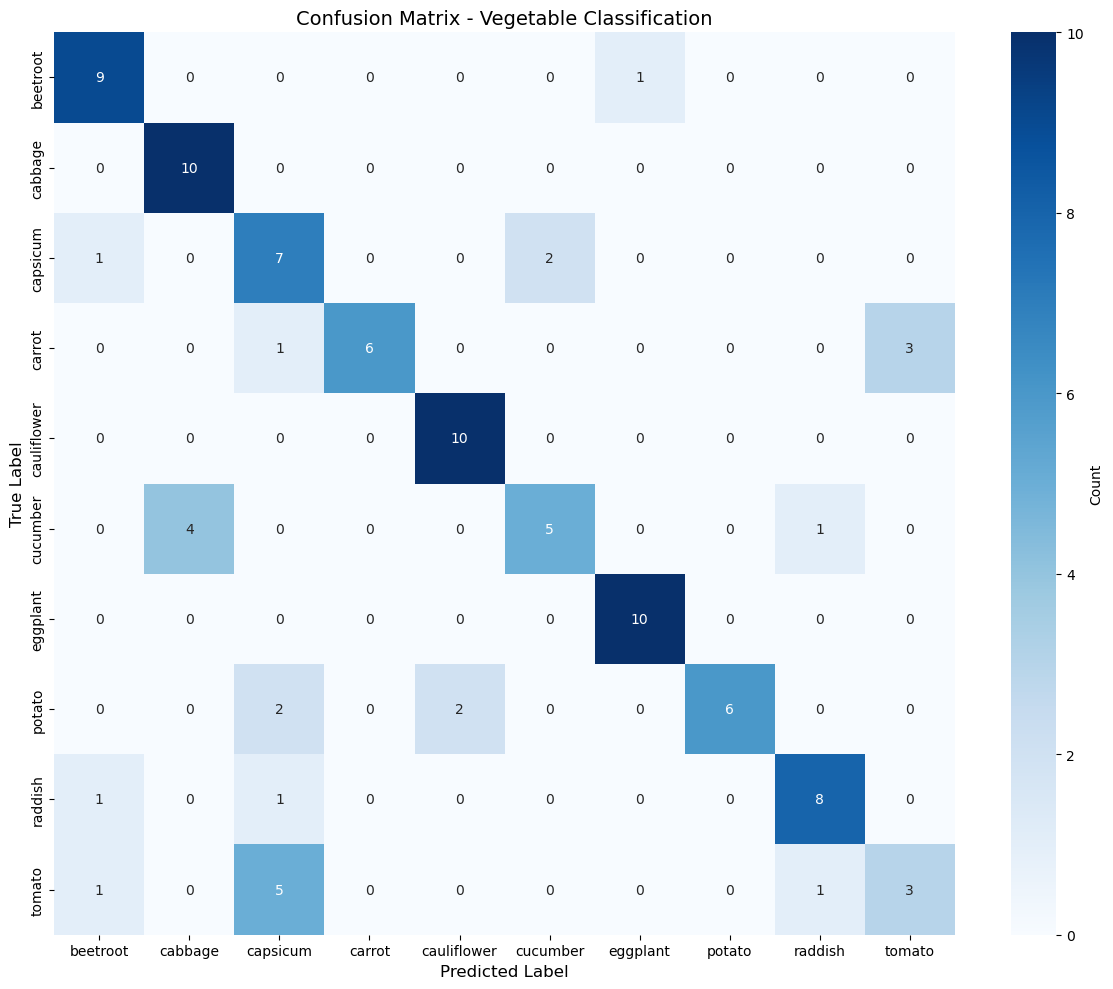

In [41]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Count"}
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Vegetable Classification", fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
print("\nMost Common Misclassifications:")
print("=" * 60)

# show top 10 mistakes
mistakes = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            mistakes.append((cm[i, j], i, j))

mistakes.sort(reverse=True)

for k in range(min(10, len(mistakes))):
    count, i, j = mistakes[k]
    print(f"{class_names[i]} misclassified as {class_names[j]}: {count}")



Most Common Misclassifications:
tomato misclassified as capsicum: 5
cucumber misclassified as cabbage: 4
carrot misclassified as tomato: 3
potato misclassified as cauliflower: 2
potato misclassified as capsicum: 2
capsicum misclassified as cucumber: 2
tomato misclassified as raddish: 1
tomato misclassified as beetroot: 1
raddish misclassified as capsicum: 1
raddish misclassified as beetroot: 1


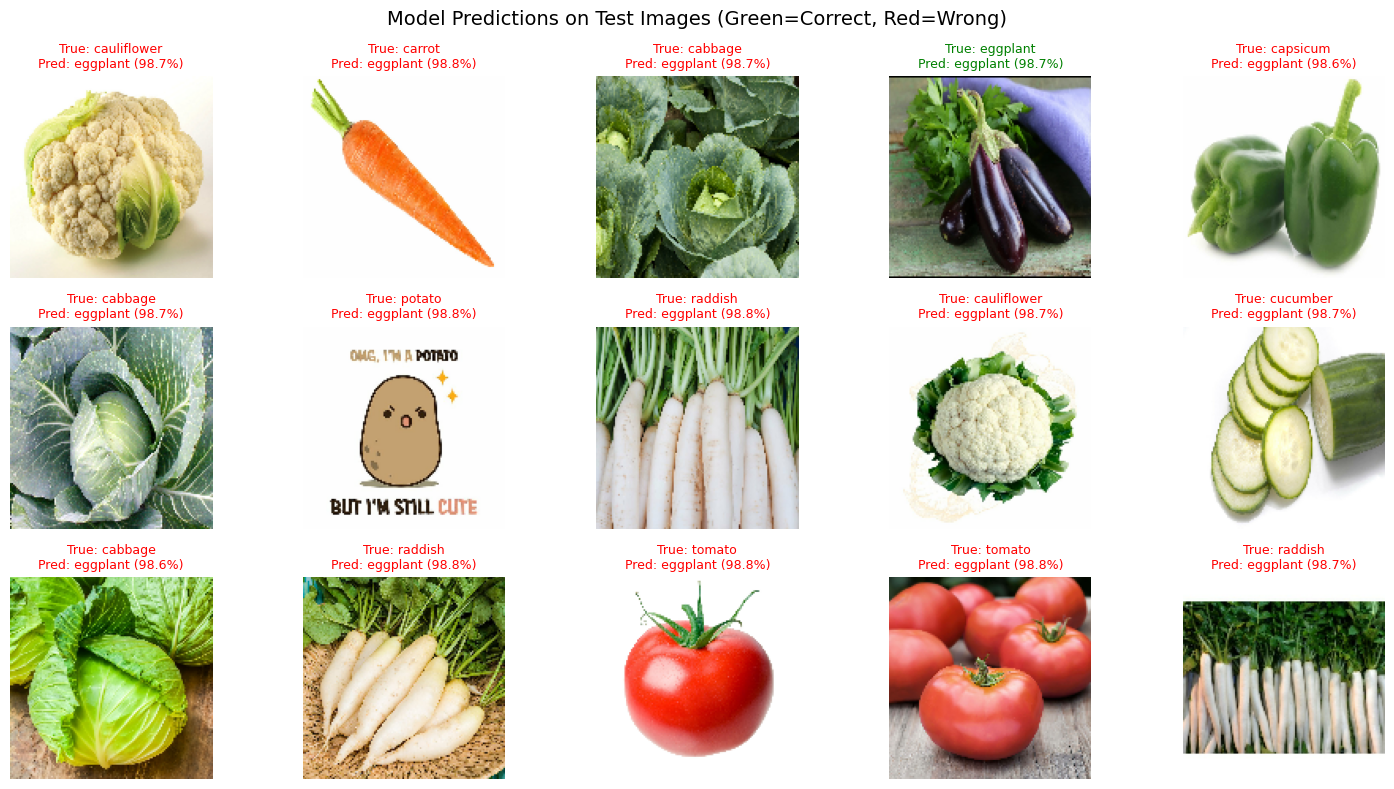

In [43]:
plt.figure(figsize=(15, 8))

num_images = 15
all_images = []
all_labels = []


for images, labels in test_ds.take(10):
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

random_indices = np.random.choice(len(all_images), num_images, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(3, 5, i + 1)

    img = all_images[idx].astype("uint8")
    true_label = class_names[int(all_labels[idx])]

    img_input = tf.expand_dims(tf.cast(img, tf.float32), axis=0) / 255.0
    pred_probs = model.predict(img_input, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    pred_label = class_names[pred_idx]
    confidence = pred_probs[pred_idx] * 100

    color = "green" if true_label == pred_label else "red"

    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
              fontsize=9, color=color)
    plt.axis("off")

plt.suptitle("Model Predictions on Test Images (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
model.save("vegetable_classifier_1.h5")
print("\nSaved model as: vegetable_classifier.keras")


Saved model as: vegetable_classifier.keras


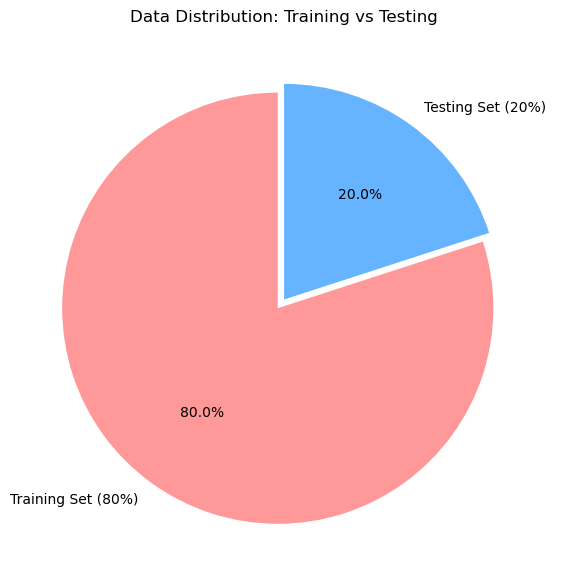

In [45]:
import matplotlib.pyplot as plt

# உங்கள் கோப்பில் உள்ள தரவுகளின் எண்ணிக்கை (உதாரணத்திற்கு)
train_count = 800  # உங்கள் மொத்த ட்ரெய்னிங் படங்கள்
test_count = 200   # உங்கள் மொத்த டெஸ்டிங் படங்கள்

labels = ['Training Set (80%)', 'Testing Set (20%)']
sizes = [train_count, test_count]
colors = ['#ff9999','#66b3ff']

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0))
plt.title("Data Distribution: Training vs Testing")
plt.show()